In [8]:
# ==========================================
# Jupyter 환경에서 한글 폰트 직접 등록 (NanumGothic, URL 안정 버전)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os, urllib.request

# 1️⃣ 폰트 저장 경로 설정
font_dir = "/home/user/.fonts"
os.makedirs(font_dir, exist_ok=True)
font_path = os.path.join(font_dir, "NanumGothic.ttf")

# 2️⃣ 안정적인 다운로드 URL (Google Fonts CDN)
font_url = (
    "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
)

if not os.path.exists(font_path):
    print("📦 나눔고딕 폰트 다운로드 중...")
    urllib.request.urlretrieve(font_url, font_path)
    print("✅ 나눔고딕 폰트 다운로드 및 저장 완료")
else:
    print("✅ 이미 나눔고딕 폰트가 존재합니다.")

# 3️⃣ 폰트 등록 및 적용
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"🎨 현재 적용된 폰트: {plt.rcParams['font.family']}")

✅ 이미 나눔고딕 폰트가 존재합니다.
🎨 현재 적용된 폰트: ['NanumGothic']


In [2]:
# ==========================================
# [1] 데이터 로드
# ==========================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

data_dir = "/home/user/ai/AnKiHyeon/공공데이터_원본/전북특별자치도_도로유지보수이력_공간정보_20211221"

paths = {
    "overlay": f"{data_dir}/전라북도_지방도_덧씌우기_사업_대상지.shp",
    "repair": f"{data_dir}/전라북도__지방도_포트홀_보수_데이터.shp",
    "complaint": f"{data_dir}/전라북도_지방도_포트홀_민원_발생_데이터..shp",
}

dfs = {}
for key, path in paths.items():
    df = gpd.read_file(path, encoding="euc-kr")
    dfs[key] = df
    print(
        f"✅ {key.upper()} 로드 완료 | 행 {len(df):,}개 | 좌표계 {df.crs} | geometry: {df.geom_type.unique()}"
    )
    display(df.head(3))

✅ OVERLAY 로드 완료 | 행 211개 | 좌표계 EPSG:5181 | geometry: ['Polygon']


,노선명,사업명,연장,시 점,종 점,연도,시점 위도,시점 경도,종점 위도,종점 경도,geometry
0,지방도 709호선,군산 회현 외 2지구 덧씌우기 공사,0.6km,전라북도 군산시 회현면 고사리 168-11,전라북도 군산시 회현면 고사리 산 10-2,2018,35.930134,126.766065,35.924449,126.766069,"POLYGON ((179187.8 269686.418, 179186.302 2696..."
1,지방도 718호선,군산 회현 외 2지구 덧씌우기 공사,0.4km,전라북도 군산시 회현면 학당리 862-2,전라북도 군산시 회현면 금광리 224-2,2018,35.910924,126.763811,35.911692,126.759462,"POLYGON ((178223.699 267979.802, 178195.286 26..."
2,지방도 718호선,군산 회현 외 2지구 덧씌우기 공사,1.7km,전라북도 군산시 대야면 지경리 1982-8,전라북도 군산시 대야면 지경리 1196-8,2018,35.938464,126.798830,35.931731,126.782163,"POLYGON ((180474.921 270222.583, 180447.918 27..."


✅ REPAIR 로드 완료 | 행 231개 | 좌표계 EPSG:4326 | geometry: ['Point']


,연도,일 자,노선명,작업구역,위치,보수내용,위도,경도,geometry
0,2021,1월 21일,713,이서 - 대문안,전라북도 김제시 만경읍 송상리 428-5,포트홀,35.872253,126.824811,POINT (126.82481 35.87225)
1,2021,1월 21일,716,이서 - 김제시계,전라북도 완주군 이서면 은교리 산224-1,포트홀,35.820121,127.006067,POINT (127.00607 35.82012)
2,2021,1월 21일,702,와룡 - 진봉,전라북도 김제시 진봉면 고사리 18-3,포트홀,35.856538,126.765757,POINT (126.76576 35.85654)


✅ COMPLAINT 로드 완료 | 행 252개 | 좌표계 EPSG:4326 | geometry: ['Point']


,민원일자,민원위치,민원내용,위도,경도,geometry
0,2018-01-06,전라북도 군산시 임피면 영창리 831-2번지 일원 (지방도 718호선),지방도 718호선 대령마을 부근 가상과속방지턱 설치 관련 진행상황 요청,35.971774,126.877085,POINT (126.87709 35.97177)
1,2018-01-09,전라북도 고창군 해리면 고성리 일원 (국지도15호선),회전교차로(송산교차로)설치 요청 건 진행사항 문의,35.446368,126.553224,POINT (126.55322 35.44637)
2,2018-02-18,전라북도 순창군 유등면 창신리 272-9번지 일원 (지방도 730호선),과속방지턱 설치요청,35.365969,127.160204,POINT (127.1602 35.36597)


In [4]:
for name, df in dfs.items():
    print(f"\n📊 [{name.upper()}] 데이터 요약")
    print(df.info())
    print("\n🔹 결측치 개수:")
    print(df.isna().sum().sort_values(ascending=False).head(10))
    print("\n🔹 중복 레코드 수:", df.duplicated().sum())
    print("-" * 80)


📊 [OVERLAY] 데이터 요약
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   노선명       211 non-null    object  
 1   사업명       211 non-null    object  
 2   연장        211 non-null    object  
 3   시 점       211 non-null    object  
 4   종 점       211 non-null    object  
 5   연도        211 non-null    int64   
 6   시점 위도     211 non-null    float64 
 7   시점 경도     211 non-null    float64 
 8   종점 위도     211 non-null    float64 
 9   종점 경도     211 non-null    float64 
 10  geometry  211 non-null    geometry
dtypes: float64(4), geometry(1), int64(1), object(5)
memory usage: 18.3+ KB
None

🔹 결측치 개수:
노선명      0
사업명      0
연장       0
시 점      0
종 점      0
연도       0
시점 위도    0
시점 경도    0
종점 위도    0
종점 경도    0
dtype: int64

🔹 중복 레코드 수: 0
--------------------------------------------------------------------------------

📊 [REPAIR] 데이터 요약
<class 'geopandas

📏 덧씌우기 수치형 컬럼: Index(['연도', '시점 위도', '시점 경도', '종점 위도', '종점 경도'], dtype='object')


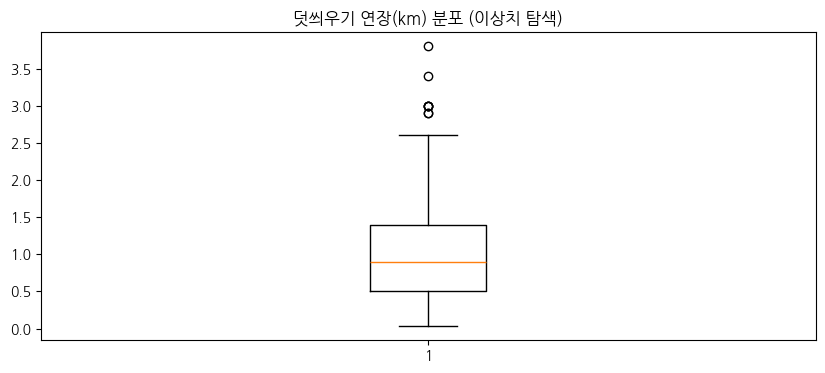

In [7]:
numeric_cols = dfs["overlay"].select_dtypes(include=["float64", "int64"]).columns
print("📏 덧씌우기 수치형 컬럼:", numeric_cols)

dfs["overlay"][numeric_cols].describe()

plt.figure(figsize=(10, 4))
plt.boxplot(dfs["overlay"]["연장"].str.replace("km", "").astype(float))
plt.title("덧씌우기 연장(km) 분포 (이상치 탐색)")
plt.show()

In [9]:
repair = dfs["repair"]
complaint = dfs["complaint"]

# 보수 일자 전처리
repair["일자_정제"] = (
    repair["연도"].astype(str)
    + "-"
    + repair["일 자"].str.replace("월", "-").str.replace("일", "")
)
repair["일자_정제"] = pd.to_datetime(repair["일자_정제"], errors="coerce")

# 민원 일자
complaint["민원일자"] = pd.to_datetime(complaint["민원일자"], errors="coerce")

print("📆 보수 날짜 샘플:", repair["일자_정제"].dropna().head(3).to_list())
print("📆 민원 날짜 샘플:", complaint["민원일자"].dropna().head(3).to_list())

📆 보수 날짜 샘플: []
📆 민원 날짜 샘플: [Timestamp('2018-01-06 00:00:00'), Timestamp('2018-01-09 00:00:00'), Timestamp('2018-02-18 00:00:00')]


/tmp/ipykernel_1904032/2916185704.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repair["일자_정제"] = pd.to_datetime(repair["일자_정제"], errors="coerce")


In [10]:
for name, df in dfs.items():
    invalid = df[~df.is_valid]
    print(f"⚙️ {name} 유효하지 않은 geometry:", len(invalid))
    if len(invalid) > 0:
        dfs[name].loc[~df.is_valid, "geometry"] = df.loc[
            ~df.is_valid, "geometry"
        ].buffer(0)

# 좌표계 통일 (WGS84로)
for name in dfs:
    dfs[name] = dfs[name].to_crs(epsg=4326)

⚙️ overlay 유효하지 않은 geometry: 0
⚙️ repair 유효하지 않은 geometry: 0
⚙️ complaint 유효하지 않은 geometry: 0


/tmp/ipykernel_1904032/902275427.py:5: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


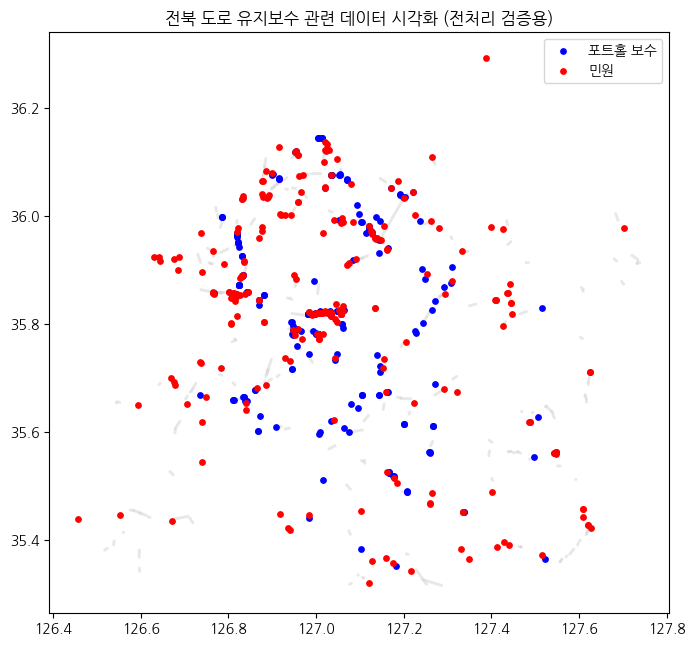

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))
dfs["overlay"].plot(ax=ax, color="lightgray", alpha=0.5, label="덧씌우기")
dfs["repair"].plot(ax=ax, color="blue", markersize=15, label="포트홀 보수")
dfs["complaint"].plot(ax=ax, color="red", markersize=15, label="민원")
plt.legend()
plt.title("전북 도로 유지보수 관련 데이터 시각화 (전처리 검증용)")
plt.show()

In [17]:
# ==========================================
# [EDA Markdown Report Generator]
# 전북 도로 유지보수 데이터 분석 + 결과 마크다운 저장
# ==========================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import matplotlib
from shapely.ops import nearest_points
import os

# ---------- [환경설정] ----------
# 한글 폰트 설정
if platform.system() == "Linux":
    !apt-get -qq -y install fonts-nanum > /dev/null
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    fm.fontManager.addfont(font_path)
    plt.rc('font', family='NanumGothic')
elif platform.system() == "Darwin":
    plt.rc('font', family='AppleGothic')
elif platform.system() == "Windows":
    plt.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ---------- [입력 경로 설정] ----------
data_dir = "/home/user/ai/AnKiHyeon/공공데이터_원본/전북특별자치도_도로유지보수이력_공간정보_20211221"
paths = {
    "overlay": f"{data_dir}/전라북도_지방도_덧씌우기_사업_대상지.shp",
    "repair": f"{data_dir}/전라북도__지방도_포트홀_보수_데이터.shp",
    "complaint": f"{data_dir}/전라북도_지방도_포트홀_민원_발생_데이터..shp"
}

# ---------- [데이터 로드] ----------
dfs = {name: gpd.read_file(path, encoding="euc-kr") for name, path in paths.items()}
for name in dfs:
    dfs[name] = dfs[name].to_crs(epsg=4326)

overlay = dfs["overlay"]
repair = dfs["repair"]
complaint = dfs["complaint"]

# ---------- [1️⃣ 데이터 구조 요약] ----------
summary_md = "# 📊 전북 도로 유지보수 데이터 EDA 통합 보고서\n"
summary_md += "본 문서는 3종 SHP 데이터를 기반으로 한 데이터 탐색(EDA) 결과 요약입니다.\n\n"

for name, df in dfs.items():
    summary_md += f"## ✅ {name.upper()} 데이터 개요\n"
    summary_md += f"- 총 행 수: **{len(df):,}개**\n"
    summary_md += f"- 좌표계: `{df.crs}`\n"
    summary_md += f"- 컬럼 수: {len(df.columns)}개\n\n"
    summary_md += f"**컬럼 목록:** {', '.join(df.columns)}\n\n"

# ---------- [2️⃣ 결측치 및 중복] ----------
for name, df in dfs.items():
    nulls = df.isna().sum().sort_values(ascending=False).head(5)
    dups = df.duplicated().sum()
    summary_md += f"### 🧮 {name.upper()} 결측치·중복 현황\n"
    summary_md += f"- 중복 행 수: **{dups}개**\n"
    summary_md += f"```\n{nulls.to_string()}\n```\n\n"

# ---------- [3️⃣ 덧씌우기 연장 통계 및 시각화] ----------
overlay["연장_km"] = overlay["연장"].str.replace("km","").astype(float)
plt.figure(figsize=(8,4))
plt.boxplot(overlay["연장_km"], patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title("덧씌우기 구간 연장(km) 이상치 탐색")
plt.ylabel("길이(km)")
plt.savefig("덧씌우기_연장_분포.png", bbox_inches="tight")
plt.close()

summary_md += "### 📏 덧씌우기 사업 연장 통계\n"
summary_md += "```\n" + str(overlay["연장_km"].describe()) + "\n```\n"
summary_md += "![덧씌우기 연장 분포](덧씌우기_연장_분포.png)\n\n"

# ---------- [4️⃣ 날짜 필드 정제] ----------
repair["일자_정제"] = (
    repair["연도"].astype(str) + "-" +
    repair["일 자"].str.replace("월","-").str.replace("일","")
)
repair["일자_정제"] = pd.to_datetime(repair["일자_정제"], errors="coerce")
complaint["민원일자"] = pd.to_datetime(complaint["민원일자"], errors="coerce")

summary_md += "### 📆 날짜 필드 정제 결과\n"
summary_md += f"- 보수 데이터 변환 성공: {repair['일자_정제'].notna().sum()}건\n"
summary_md += f"- 민원 데이터 변환 성공: {complaint['민원일자'].notna().sum()}건\n\n"

# ---------- [5️⃣ 민원-보수 거리 계산] ----------
repair["min_dist_to_complaint_m"] = repair.geometry.apply(
    lambda x: complaint.distance(x).min() * 111000
)
plt.figure(figsize=(8,4))
plt.hist(repair["min_dist_to_complaint_m"], bins=40, color='lightblue', edgecolor='gray')
plt.axvline(500, color='red', linestyle='--', label='500m 기준')
plt.legend()
plt.title("민원-보수 거리 분포 (m)")
plt.xlabel("거리 (m)")
plt.ylabel("빈도")
plt.savefig("민원_보수_거리분포.png", bbox_inches="tight")
plt.close()

summary_md += "### 📍 민원-보수 거리 통계\n"
summary_md += "```\n" + str(repair["min_dist_to_complaint_m"].describe()) + "\n```\n"
summary_md += "![민원-보수 거리 분포](민원_보수_거리분포.png)\n\n"

# ---------- [6️⃣ 덧씌우기 구간 포함률] ----------
overlay_union = overlay.buffer(0.0005).unary_union
repair["in_overlay"] = repair.geometry.apply(lambda g: overlay_union.contains(g))
summary_md += "### 🏗️ 덧씌우기 구간 내 보수 포함 비율\n"
summary_md += f"- 포함 비율: **{repair['in_overlay'].mean() * 100:.2f}%**\n\n"

# ---------- [7️⃣ 시각화 통합 지도] ----------
fig, ax = plt.subplots(figsize=(8,8))
overlay.plot(ax=ax, color="lightgray", alpha=0.4, label="덧씌우기")
repair.plot(ax=ax, color="blue", markersize=15, label="보수")
complaint.plot(ax=ax, color="red", markersize=15, label="민원")
plt.legend()
plt.title("전북 도로 유지보수 공간 분포 (민원-보수-덧씌우기)")
plt.savefig("전북_유지보수_통합지도.png", bbox_inches="tight")
plt.close()
summary_md += "![전북 도로 유지보수 통합 지도](전북_유지보수_통합지도.png)\n\n"

# ---------- [8️⃣ 주요 지표 요약] ----------
summary_md += "## 📈 주요 지표 요약\n"
summary_md += "| 지표 | 설명 | 값 |\n|------|------|------|\n"
summary_md += f"| 평균 민원-보수 거리(m) | 대응 반경 평균 | {repair['min_dist_to_complaint_m'].mean():.2f} |\n"
summary_md += f"| 500m 이하 대응률 | 민원 근접 보수 비율 | {(repair['min_dist_to_complaint_m'] < 500).mean()*100:.2f}% |\n"
summary_md += f"| 덧씌우기 포함률 | 사업구간 내 보수 비율 | {repair['in_overlay'].mean()*100:.2f}% |\n"

# ---------- [9️⃣ 보고서 저장] ----------
output_path = os.path.join(os.getcwd(), "전북_도로유지보수_EDA_결과보고서.md")
with open(output_path, "w", encoding="utf-8") as f:
    f.write(summary_md)

print(f"✅ Markdown 보고서 생성 완료: {output_path}")


E: 잠금 파일 /var/lib/dpkg/lock-frontend 파일을 열 수 없습니다 - open (13: Permission denied)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


/tmp/ipykernel_1904032/3289163592.py:81: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  repair["일자_정제"] = pd.to_datetime(repair["일자_정제"], errors="coerce")
/tmp/ipykernel_1904032/3289163592.py:90: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda x: complaint.distance(x).min() * 111000
/tmp/ipykernel_1904032/3289163592.py:107: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  overlay_union = overlay.buffer(0.0005).unary_union
/tmp/ipykernel_1904032/3289163592.py:107: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  overlay_

✅ Markdown 보고서 생성 완료: /home/user/ai/AnKiHyeon/전북_도로유지보수_EDA_결과보고서.md


/tmp/ipykernel_1904032/3289163592.py:117: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
